/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/var/folders/m2/4cg3yx5920q_xr4pt77l79f80000gn/T/ipykernel_14975/1358749244.py:160: F

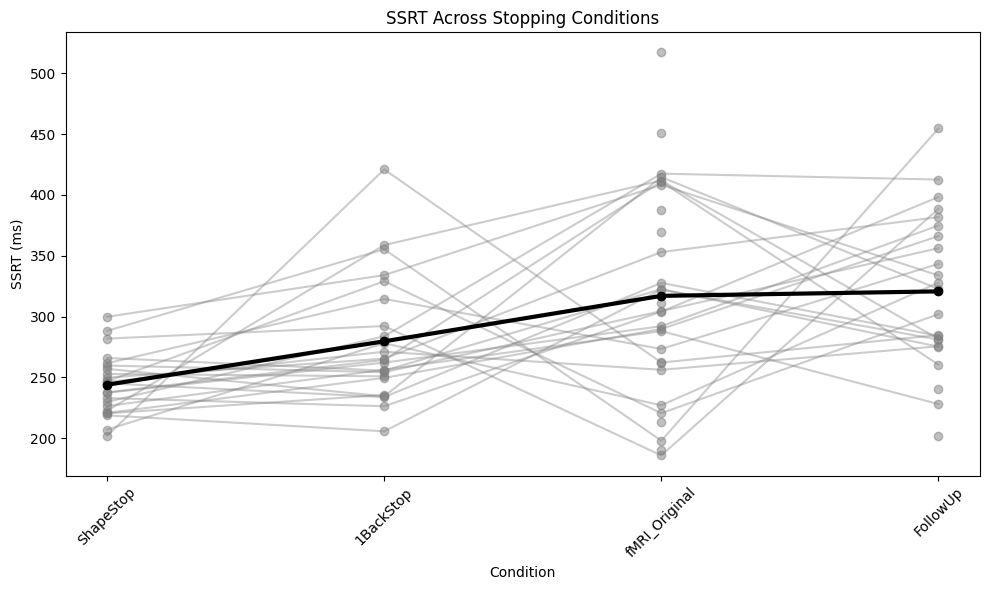

In [7]:
import pandas as pd
import matplotlib.pyplot as plt
!pip install openpyxl

import seaborn as sns
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
!pip install openpyxl

# ---------------------------
# 1. Define files and their column mappings
# ---------------------------
files_info = {
    "fMRI_Original": {
        "file": "/Users/elizabethkudriavtsev/Downloads/thebeastdataset/BeastfMRIN30.xlsx",
        "subject_col": "SubjID",
        "rt_col": "RT",
        "stop_acc_col": "StopAcc",
        "ssd_col": "SSD",
        "stop_go_col": "Stop1OrNoStop2",
        "go_code": 2,
        "stop_code": 1,
        "stim_col": "Target1NonTarget2TempNonTarget3",
        "stim_map": {1: "Target", 2: "Non-target", 3: "Lure"}
    },
    "FollowUp": {
        "file": "/Users/elizabethkudriavtsev/Downloads/thebeastdataset/N23NonFMRIBeast.xlsx",
        "subject_col": "subject_id",
        "rt_col": "RT",
        "stop_acc_col": "stop_acc",
        "ssd_col": "SSD_target",
        "stop_go_col": "SS_trial_type",
        "go_code": "go",
        "stop_code": "stop",
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "1BackStop": {
        "file": "/Users/elizabethkudriavtsev/Downloads/thebeastdataset/1BackStoppingN23.xlsx",
        "subject_col": "subject_id",
        "rt_col": "rt",
        "stop_acc_col": "stop_acc",
        "ssd_col": "SSD_target",
        "stop_go_col": "stop_trial_type",
        "go_code": "go",
        "stop_code": "stop",
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "NBackNoStop": {  # no stop trials
        "file": "/Users/elizabethkudriavtsev/Downloads/thebeastdataset/NBackNoStopN23.xlsx",
        "subject_col": "subject_id",
        "rt_col": "rt",
        "stop_acc_col": None,
        "ssd_col": None,
        "stop_go_col": None,
        "go_code": None,
        "stop_code": None,
        "stim_col": "adaptive_trial_type",
        "stim_map": {"target": "Target", "non-target": "Non-target", "temp-non-target": "Lure"}
    },
    "ShapeStop": {
    "file": "/Users/elizabethkudriavtsev/Downloads/thebeastdataset/StopNoNBackN23.xlsx",
    "subject_col": "subject_ID",
    "rt_col": "rt",
    "stop_acc_col": "stop_acc",
    "ssd_col": "SS_delay",
    "stop_go_col": "SS_trial_type",
    "go_code": "go",     # <-- strings, not 0/1
    "stop_code": "stop",
    "shape_col": "go_stim",
    "shape_map": {"black_circle": "Circle", "black_triangle": "Triangle"}
}
}

# ---------------------------
# 2. SSRT computation function
# ---------------------------
def compute_ssrt(df, stop_go_col, stop_acc_col, ssd_col, rt_col, go_code, stop_code):
    df = df.copy()
    
    # skip if no stop trials (e.g., NBackNoStop)
    if stop_go_col is None or stop_acc_col is None or ssd_col is None:
        return np.nan
    
    # Map stop/go to 1 = stop, 2 = go
    df['stop_trial'] = df[stop_go_col].map({stop_code: 1, go_code: 2})
    go_trials = df[df['stop_trial'] == 2]
    stop_trials = df[df['stop_trial'] == 1]
    
    if len(go_trials) == 0 or len(stop_trials) == 0:
        return np.nan
    
    p_respond = 1 - stop_trials[stop_acc_col].mean()
    go_rts = np.sort(go_trials[rt_col].values)
    n_idx = int(np.ceil(p_respond * len(go_rts))) - 1
    n_idx = max(n_idx, 0)
    nth_rt = go_rts[n_idx]
    mean_ssd = stop_trials[ssd_col].mean()
    
    return nth_rt - mean_ssd

# ---------------------------
# 3. Loop through files and compute SSRT
# ---------------------------
ssrt_list = []

for cond_name, info in files_info.items():
    df = pd.read_excel(info['file'])
    df.columns = df.columns.str.strip()  # remove whitespace
    
    # Robust subject column detection
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    if subject_col is None:
        raise ValueError(f"Subject column not found in {cond_name} dataset")
    df.rename(columns={subject_col: 'subject'}, inplace=True)
    
    for subj in df['subject'].unique():
        subj_df = df[df['subject'] == subj]
        try:
            ssrt = compute_ssrt(
                subj_df,
                stop_go_col=info.get('stop_go_col'),
                stop_acc_col=info.get('stop_acc_col'),
                ssd_col=info.get('ssd_col'),
                rt_col=info['rt_col'],
                go_code=info.get('go_code'),
                stop_code=info.get('stop_code')
            )
            ssrt_list.append({"subject": subj, "Condition": cond_name, "SSRT": ssrt})
        except Exception as e:
            print(f"Skipping subject {subj} in {cond_name}: {e}")

ssrt_df = pd.DataFrame(ssrt_list)

# Filter extreme SSRTs
ssrt_df = ssrt_df[(ssrt_df['SSRT'] >= 100) & (ssrt_df['SSRT'] <= 600)]

# ---------------------------
# 4. Plot SSRT across stopping conditions
# ---------------------------
plt.figure(figsize=(10,6))

# Correct order: ShapeStop, 1BackStop, fMRI_Original, FollowUp
condition_order = ["ShapeStop", "1BackStop", "fMRI_Original", "FollowUp"]

# Apply categorical ordering
ssrt_df['Condition'] = pd.Categorical(ssrt_df['Condition'], categories=condition_order, ordered=True)

# Spaghetti plot (each subject)
for sub in ssrt_df['subject'].unique():
    sub_df = ssrt_df[ssrt_df['subject'] == sub].set_index('Condition').reindex(condition_order)
    plt.plot(condition_order, sub_df['SSRT'], color='gray', alpha=0.4)

# Mean line
mean_df = ssrt_df.groupby('Condition')['SSRT'].mean().reindex(condition_order)
plt.plot(condition_order, mean_df, color='black', linewidth=3, marker='o')

# Overlay individual points
for cond in condition_order:
    y_vals = ssrt_df[ssrt_df['Condition'] == cond]['SSRT']
    x_vals = [cond]*len(y_vals)
    plt.scatter(x_vals, y_vals, color='gray', alpha=0.5)

plt.xlabel("Condition")
plt.ylabel("SSRT (ms)")
plt.title("SSRT Across Stopping Conditions")
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

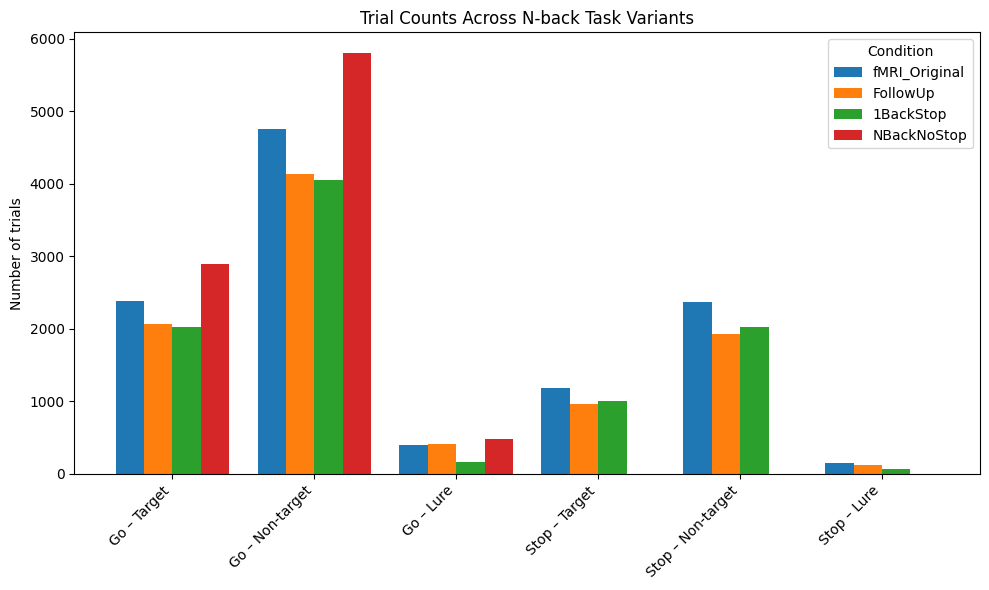

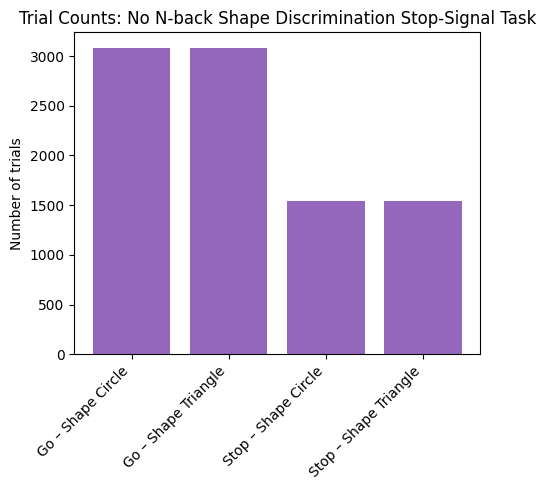

In [10]:
# Trial count per condition x trial type


# ---------------------------
# 1. Define trial types to include
# ---------------------------
trial_types_order = [
    "Go – Target", "Go – Non-target", "Go – Lure",
    "Stop – Target", "Stop – Non-target", "Stop – Lure"
]

# N-back tasks (all together)
nback_tasks = ["fMRI_Original", "FollowUp", "1BackStop", "NBackNoStop"]

# ---------------------------
# 2. Pivot data for grouped bar plot
# ---------------------------
# Filter only N-back tasks
nback_counts = trial_counts[trial_counts["task"].isin(nback_tasks)]

# Pivot so that rows = trial_type_label, columns = task
pivot_df = nback_counts.pivot_table(
    index="trial_type_label",
    columns="task",
    values="n_trials",
    fill_value=0
)

# Reorder rows to desired trial type order
pivot_df = pivot_df.reindex(trial_types_order)

# ---------------------------
# 3. Plot grouped bar chart
# ---------------------------
fig, ax = plt.subplots(figsize=(10,6))

bar_width = 0.2
x = np.arange(len(trial_types_order))

colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728"]  # assign one color per condition

for i, task in enumerate(nback_tasks):
    ax.bar(x + i*bar_width, pivot_df[task], width=bar_width, label=task, color=colors[i])

ax.set_xticks(x + bar_width*1.5)  # center x-ticks
ax.set_xticklabels(trial_types_order, rotation=45, ha="right")
ax.set_ylabel("Number of trials")
ax.set_title("Trial Counts Across N-back Task Variants")
ax.legend(title="Condition")
plt.tight_layout()
plt.show()

# ---------------------------
# 4. Plot ShapeStop separately
# ---------------------------
shape_data = trial_counts[trial_counts["task"] == "ShapeStop"].copy()

plt.figure(figsize=(5,5))
plt.bar(shape_data["trial_type_label"], shape_data["n_trials"], color="#9467bd")
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of trials")
plt.title("Trial Counts: No N-back Shape Discrimination Stop-Signal Task")
plt.tight_layout()
plt.show()


/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)
/Users/elizabethkudriavtsev/miniconda3/lib/python3.11/site-packages/openpyxl/worksheet/_reader.py:329: UserWarning: Unknown extension is not supported and will be removed
  warn(msg)


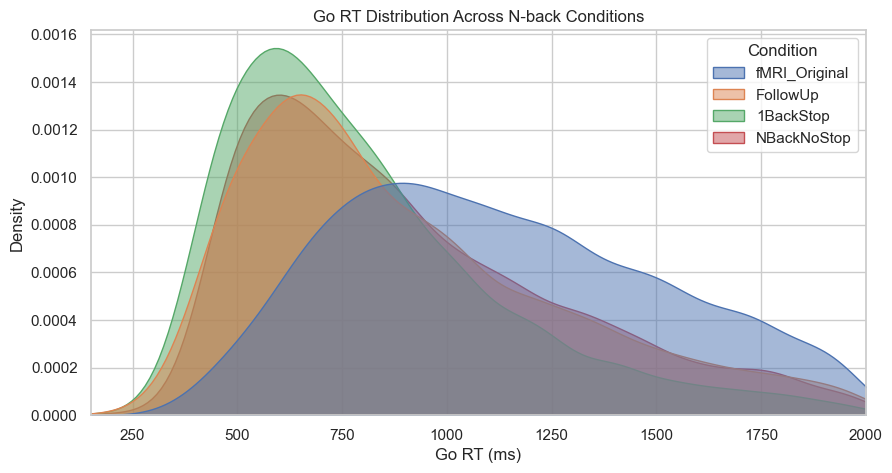

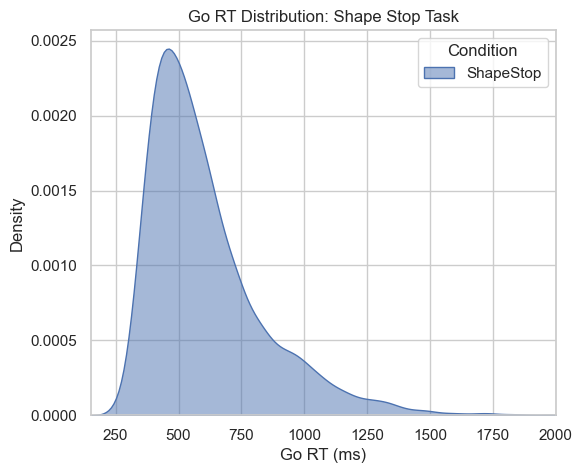

In [14]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# 1. Prepare data for Go RTs
# ---------------------------
rt_list = []

for task, info in files_info.items():
    df = pd.read_excel(info["file"])
    
    # Clean subject column
    subject_col = next((c for c in df.columns if info['subject_col'].lower() in c.lower()), None)
    df.rename(columns={subject_col: 'subject'}, inplace=True)
    
    # Only include tasks with a stop/go column for Go RT selection
    if info.get("stop_go_col") is not None:
        # Filter Go trials and realistic RTs
        df = df[(df[info["rt_col"]] >= 150) & (df[info["rt_col"]] <= 2000)]
        df = df[df[info["stop_go_col"]] == info["go_code"]]
        df["Condition"] = task
        df["RT"] = df[info["rt_col"]]
        rt_list.append(df[["subject", "Condition", "RT"]])
    else:
        # For tasks with no stop/go (ShapeStop), include all RTs within range
        df = df[(df[info["rt_col"]] >= 150) & (df[info["rt_col"]] <= 2000)]
        df["Condition"] = task
        df["RT"] = df[info["rt_col"]]
        rt_list.append(df[["subject", "Condition", "RT"]])

rt_df = pd.concat(rt_list, ignore_index=True)

# ---------------------------
# 2. Split into N-back vs ShapeStop
# ---------------------------
nback_tasks = ["fMRI_Original", "FollowUp", "1BackStop", "NBackNoStop"]
shape_task = ["ShapeStop"]

rt_nback = rt_df[rt_df["Condition"].isin(nback_tasks)]
rt_shape = rt_df[rt_df["Condition"].isin(shape_task)]

# ---------------------------
# 3. Plot Go RT distributions
# ---------------------------
sns.set(style="whitegrid")

# N-back panel
plt.figure(figsize=(10,5))
sns.kdeplot(
    data=rt_nback, x="RT", hue="Condition", fill=True, common_norm=False, alpha=0.5
)
plt.xlim(150, 2000)
plt.xlabel("Go RT (ms)")
plt.ylabel("Density")
plt.title("Go RT Distribution Across N-back Conditions")
plt.show()

# ShapeStop panel
plt.figure(figsize=(6,5))
sns.kdeplot(
    data=rt_shape, x="RT", hue="Condition", fill=True, common_norm=False, alpha=0.5
)
plt.xlim(150, 2000)
plt.xlabel("Go RT (ms)")
plt.ylabel("Density")
plt.title("Go RT Distribution: Shape Stop Task")
plt.show()

